# 22DM015 Final Project — Financial PhraseBank
**Part 2 — BERT track (BERT, augmentation eval)**

## Preparations

In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- Reproducibility seed (required by the assignment) ---
import os, random, sys, logging, warnings

# Environment + logging setup that MUST run BEFORE importing transformers/torch.
# Tell transformers to skip its TensorFlow/Flax/Keras probe (we use PyTorch only).
# This prevents tf_keras from being imported, which is what emits the
# "tf.losses.sparse_softmax_cross_entropy is deprecated" notice.
os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")   # silence TF C++ logs if it still loads
# On Apple Silicon, let any op not yet implemented for the MPS backend fall back to CPU
# instead of erroring out. No-op on CUDA/CPU machines.
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
logging.getLogger("tensorflow").setLevel(logging.ERROR)
# Silence the cosmetic "Redirects are currently not supported in Windows or MacOs" NOTE
# emitted by torch.distributed.elastic.multiprocessing.redirects when Trainer is imported
# on Windows/macOS. No-op on Linux.
logging.getLogger("torch.distributed.elastic.multiprocessing.redirects").setLevel(logging.ERROR)
# Silence torchao's "Skipping import of cpp extensions due to incompatible torch version"
# message (https://github.com/pytorch/ao/issues/2919). We don't use torchao kernels here,
# so the Python fallbacks are fine. Covers both the logger and warnings.warn paths.
logging.getLogger("torchao").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=r".*Skipping import of cpp extensions.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed, EarlyStoppingCallback)
import transformers
# Hide the per-load model reports: the "BertForSequenceClassification LOAD REPORT"
# (expected unused pretraining heads + newly-initialized classifier head) and the
# checkpoint LayerNorm beta/gamma -> weight/bias rename notes. Both are emitted at
# warning level, so raising the threshold to error suppresses them.
transformers.logging.set_verbosity_error()
# Drop ALL tqdm progress bars: the Trainer train/eval bars (also via disable_tqdm in
# TrainingArguments), the "Writing model shards" checkpoint-save bars, and the datasets
# Map tokenization bars. The per-epoch metric LINES still print; only the bars go away.
transformers.logging.disable_progress_bar()
import datasets.utils.logging as _ds_logging
_ds_logging.disable_progress_bar()

# Pick the best available accelerator: CUDA (NVIDIA) > MPS (Apple Silicon) > CPU.
# The HF Trainer moves the model/batches onto this device automatically; we only need it
# to toggle the CPU-thread / pin-memory / precision settings in TrainingArguments below.
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'torch {torch.__version__} | device: {DEVICE}')


# Make the shared helpers importable (they live in the repo root, one level up).
sys.path.append(os.path.abspath('..'))
import data_utils as du
import eval_utils as eu

SEED = du.SEED
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [37]:
# watermark: AGLLM (AI-assisted content disclosure)
# Reusable Part-2 results chart. plot_metrics(keys) draws all six test metrics in a 3x2
# grid for the given variants, reading results.csv at call time so it always reflects the
# latest logged rows. Variants are sorted by macro-F1 and share that one order across every
# panel, so a given variant sits at the same row in all six -> easy cross-metric scan.
# Regime is shown by colour; the (full)/(probe) tag only disambiguates the BERT variants
# that appear in both regimes.
CHART_VARIANTS = {   # key -> (model, method, short label, regime)
    'random':    ('random-prior',      'baseline',             'Random',             'Baseline'),
    'rule':      ('rule-based',        'baseline',             'Rule-based',         'Baseline'),
    '2a-probe':  ('bert-base-uncased', '32-shot-frozen',       '2a 32-shot (probe)', 'Linear probe'),
    '2b-probe':  ('bert-base-uncased', 'augmented-frozen',     '2b aug (probe)',     'Linear probe'),
    '2d-probe':  ('bert-base-uncased', 'llm-generated-frozen', '2d LLM-gen (probe)', 'Linear probe'),
    '2a-full':   ('bert-base-uncased', '32-shot',              '2a 32-shot (full)',  'Full fine-tune'),
    '2b-full':   ('bert-base-uncased', 'augmented',            '2b aug (full)',      'Full fine-tune'),
    '2d-full':   ('bert-base-uncased', 'llm-generated',        '2d LLM-gen (full)',  'Full fine-tune'),
    '2e-full':   ('bert-base-uncased', 'llm-full',             '2e all-LLM (full)',  'Full fine-tune'),
    '2e-combo':  ('bert-base-uncased', 'llm-bt-combo',         '2e LLM+BT (full)',   'Full fine-tune'),
    'zero-shot': ('claude-opus-4-8',   'zero-shot',            'Zero-shot LLM',      'Zero-shot'),
}
CHART_COLORS = {'Baseline': '#9e9e9e', 'Linear probe': '#ff9800',
                'Full fine-tune': '#1976d2', 'Zero-shot': '#43a047'}
CHART_METRICS = [('accuracy', 'Accuracy'), ('f1_macro', 'F1 macro'),
                 ('f1_weighted', 'F1 weighted'), ('f1_negative', 'F1 negative'),
                 ('f1_neutral', 'F1 neutral'), ('f1_positive', 'F1 positive')]


def plot_metrics(keys, title='Part 2 — test metrics by variant (rows ordered by macro-F1)'):
    """Bar-chart grid of the six test metrics for the given CHART_VARIANTS keys.
    Reads results.csv at call time, so it always reflects the latest logged rows; a key
    with no logged TEST row yet is skipped with a [waiting] note instead of erroring."""
    res = pd.read_csv(eu.RESULTS_CSV)
    res = res[res['split'] == 'test']
    rows = []
    for k in keys:
        model, method, label, regime = CHART_VARIANTS[k]
        hit = res[(res['model'] == model) & (res['method'] == method)]
        if len(hit):
            r = hit.iloc[-1]
            rows.append({'label': label, 'regime': regime,
                         **{mk: float(r[mk]) for mk, _ in CHART_METRICS}})
        else:
            print(f'[waiting] no logged row yet for: {label}')
    if not rows:
        print('[waiting] nothing to plot yet')
        return
    rows.sort(key=lambda d: d['f1_macro'])            # one fixed order shared by every panel
    labels = [d['label'] for d in rows]
    bar_colors = [CHART_COLORS[d['regime']] for d in rows]

    fig, axes = plt.subplots(3, 2, figsize=(12, 11), sharey=True)
    for ax, (mk, mtitle) in zip(axes.ravel(), CHART_METRICS):
        vals = [d[mk] for d in rows]
        ax.barh(labels, vals, color=bar_colors)
        ax.set_xlim(0, 1)
        ax.set_title(mtitle, fontsize=10)
        for y, v in enumerate(vals):
            ax.text(v + 0.01, y, f'{v:.2f}', va='center', fontsize=7)
    present = [rg for rg in CHART_COLORS if any(d['regime'] == rg for d in rows)]
    handles = [plt.Rectangle((0, 0), 1, 1, color=CHART_COLORS[rg]) for rg in present]
    fig.legend(handles, present, loc='lower center', ncol=len(present), fontsize=9)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0.04, 1, 0.97])
    plt.show()

Last run: 2026-06-17 01:26:28


In [32]:
# watermark: AGLLM (AI-assisted content disclosure)
splits = du.load_splits()            # identical train/val/test for everyone
train, val, test = splits['train'], splits['val'], splits['test']

labeled_32 = pd.read_csv('../data/labeled_32.csv')
aug = pd.read_csv('../data/augmented_32.csv')        # 32 originals + back-translation = 229 rows
gen = pd.read_csv('../data/llm_generated.csv')        # LLM-generated only (does NOT include the 32)

Last run: 2026-06-17 00:27:20


## 2a.‍ BERT with 32 labelled examples

We are fine-tuning the BERT model with 32 labeled examples from the train dataset.‍ To do this, first we tokenize the sentences so that they fit the expected input of BERT, and we mask which inputs are real and which are padding.‍ We pad up to `128`, which is well above the maximum sentence length of the data.‍ We do not need to set BERT's maximum of 512 because it adds unnecessary complexity.‍ We do this with Hugging Face's `AutoTokenizer`.‍

Next, we add a classifier layer on BERT that predicts 3 classes.‍ We use `AutoModelForSequenceClassification`, which takes the pooled CLS representation as the input to the classification layer.‍

Finally, we run the training loop via the `Trainer` API, passing the usual parameters for training.‍ We train for up to 20 epochs with early stopping on val macro-F1 (patience 3), so val selects the stopping epoch / best checkpoint.‍ We do not otherwise search hyperparameters.‍ Instead we fix the learning rate, which differs according to which of the two fine-tuning methods we use:

1.‍ Freeze BERT and train only the classifier (a linear probe on the frozen features)
2.‍ Unfreeze everything (full fine-tuning)

We implement both to separate how much comes from BERT's pretrained representation on its own (frozen) versus how much adapting the encoder to the task adds (unfrozen).‍ For the learning rate, we use `2e-5` for full fine-tuning, which only slightly changes the large pretrained backbone, and `1e-3` for the frozen linear probe, since its from-scratch classifier head needs a much larger rate to converge (at `2e-5` the head barely moves).‍ These rates are held fixed for all models to be run here for comparison.‍

In [3]:
# watermark: AGLLM (AI-assisted content disclosure)
# training parameters
if DEVICE == 'cpu':
    torch.set_num_threads(os.cpu_count() or 4)   # CPU training: use all cores
MODEL = 'bert-base-uncased'      # general BERT;
NUM_LABELS = 3
MAX_LEN = 128
EARLY_STOP_PATIENCE = 3          # epochs without val macro-F1 gain before stopping

Last run: 2026-06-16 21:55:06


In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)

tok = AutoTokenizer.from_pretrained(MODEL)

def encode(df, max_len=MAX_LEN):
    ds = Dataset.from_pandas(df[['text', 'label']], preserve_index=False)
    return ds.map(lambda b: tok(b['text'], truncation=True, padding='max_length', max_length=max_len),
                  batched=True)


def compute_metrics(eval_pred):
    # Used by the Trainer during early stopping: turns eval logits into the same metric
    # dict as eval_utils.evaluate, so 'f1_macro' (logged as 'eval_f1_macro') drives
    # best-checkpoint selection.
    preds = eval_pred.predictions.argmax(-1)
    return eu.evaluate(eval_pred.label_ids, preds)


def train_bert(train_df, out_dir, *, val_df=None, epochs=20, batch=8, max_len=MAX_LEN,
               lr=2e-5, log_epochs=False, freeze_encoder=False, patience=EARLY_STOP_PATIENCE):
    """One shared fine-tuning protocol for every experiment in this notebook.
    Runs on whatever DEVICE Preparations detected (CUDA / MPS / CPU).

    freeze_encoder=False (default) -> full fine-tuning: all ~110M params get gradients.
    freeze_encoder=True            -> freeze the BERT encoder; only the head trains.

    lr -> learning rate. We use a per-regime convention (NOT a search): 2e-5 for full
          fine-tuning (small, to nudge the pretrained backbone) vs ~1e-3 for the frozen
          linear probe (the from-scratch head needs a much larger LR to converge).

    val_df given -> EARLY STOPPING on val macro-F1: evaluate every epoch, keep the best
                    checkpoint, and stop after `patience` epochs without improvement.
                    `epochs` becomes an upper bound; the returned model is the best-on-val
                    checkpoint. val_df=None -> train the full `epochs` with no eval."""
    set_seed(SEED)                            # fresh, reproducible init per run
    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)

    if freeze_encoder:
        for p in model.base_model.parameters():   # model.base_model == model.bert here
            p.requires_grad = False
        n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in model.parameters())
        print(f'  frozen encoder -> trainable {n_train:,}/{n_total:,} ({n_train/n_total:.2%}, head only)')

    es = val_df is not None
    args = TrainingArguments(
        output_dir=out_dir, 
        seed=SEED,
        num_train_epochs=epochs, 
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=64, 
        learning_rate=lr,
        eval_strategy='epoch' if es else 'no',     # early stopping evaluates on val each epoch
        save_strategy='epoch' if es else 'no',     # must match eval_strategy to keep the best
        save_total_limit=1 if es else None,        # only the best checkpoint on disk
        load_best_model_at_end=es,                 # restore best-on-val weights after training
        metric_for_best_model='f1_macro' if es else None,   # -> monitors eval_f1_macro
        greater_is_better=True,
        logging_strategy='epoch' if log_epochs else 'no',
        report_to='none', 
        disable_tqdm=False,                        # keep the live notebook metrics TABLE 
        use_cpu=(DEVICE == 'cpu'),                 # otherwise let Trainer use CUDA/MPS
        dataloader_pin_memory=(DEVICE == 'cuda'),  # pin_memory only helps/works on CUDA
        # fp16=(DEVICE == 'cuda'),                 # optional CUDA speedup; left off so results
                                                   # stay fp32-identical across CPU/MPS/CUDA
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=encode(train_df, max_len),
        eval_dataset=encode(val_df, max_len) if es else None,
        compute_metrics=compute_metrics if es else None,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)] if es else [],
    )
    trainer.train()
    trainer.eval_max_len = max_len            # so eval_split tokenizes like training did
    return trainer


def eval_split(trainer, df, max_len=None):
    """Predict on df and score it. Defaults to the max_len the trainer was trained with."""
    max_len = max_len or getattr(trainer, 'eval_max_len', MAX_LEN)
    pred = trainer.predict(encode(df, max_len)).predictions.argmax(-1)
    return eu.evaluate(df['label'].values, pred)


def logged(method, full_row=False):
    """Latest TEST row for (MODEL, method) from the shared scoreboard. The eval module
    keys rows on (model, method, split, n_train_labeled) and no longer tracks person, so
    we match on MODEL + method here (each method has a single n in this notebook).
    Delete a row from results.csv to force that experiment to re-run."""
    if not eu.RESULTS_CSV.exists():
        return None
    r = pd.read_csv(eu.RESULTS_CSV)
    r = r[(r['model'] == MODEL) & (r['method'] == method) & (r['split'] == 'test')]
    if not len(r):
        return None
    row = r.iloc[-1]
    return row if full_row else {k: row[k] for k in eu.METRIC_KEYS}


def notes_kv(notes):
    """Parse the 'k=v; k=v' segments of a notes string into a dict (prose segments
    ignored). Used to validate cached rows against the current inputs/protocol."""
    out = {}
    for seg in str(notes).split(';'):
        if '=' in seg:
            k, v = seg.split('=', 1)
            out[k.strip()] = v.strip()
    return out


fmt = eu.fmt


def delta_vs(m, ref_method):
    ref = logged(ref_method)
    if ref is not None:
        print(f"delta macro-F1 (vs {ref_method}): "
              f"{float(m['f1_macro']) - float(ref['f1_macro']):+.4f}")

Last run: 2026-06-16 22:01:55


In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- 2a (full): 32-shot FULL fine-tuning (all params trainable), lr 2e-5 ---
# RESUME-AWARE: reuses the logged '32-shot' row. Training uses early stopping on val
# macro-F1 (val_df=val); the TEST metrics are what we log to results.csv via eu.log_result.
method, cache_dir = '32-shot', '../.cache/bert_32shot'
m = logged(method)
if m is None:
    trainer = train_bert(labeled_32, cache_dir, val_df=val, lr=2e-5, log_epochs=True, freeze_encoder=False)
    val_m = eval_split(trainer, val)
    m = eval_split(trainer, test)                      # TEST metrics -> logged below
    eu.log_result(MODEL, method, len(labeled_32), m,
                  notes=f"freeze_encoder=False; lr=2e-5; early_stop=val_f1_macro; val_f1_macro={val_m['f1_macro']:.4f}")
    print(f'[{method}] VAL :', fmt(val_m), '[trained]')
else:
    print(f'[{method}] [cached] (val macro-F1 is in the notes column of results.csv)')
shot_m = m                                              # full-FT TEST row, reused by delta_vs in later cells
print(f'2a {method} TEST:', fmt(shot_m))

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,1.120131,1.174652,0.237885,0.205961,0.137242,0.194175,0.014184,0.409524
2,1.025510,1.134108,0.251101,0.257571,0.227253,0.206061,0.157895,0.408759
3,0.903740,1.029117,0.484581,0.456044,0.545173,0.255639,0.634615,0.477876
4,0.826910,0.946170,0.660793,0.574449,0.695072,0.333333,0.825911,0.564103
5,0.730407,0.900267,0.691630,0.612706,0.721071,0.404255,0.841270,0.592593
6,0.690933,0.867643,0.682819,0.593618,0.710482,0.404040,0.851562,0.525253
7,0.611612,0.821286,0.731278,0.648102,0.751771,0.450000,0.867188,0.627119
8,0.507134,0.802595,0.753304,0.663331,0.766400,0.444444,0.874016,0.671533
9,0.465419,0.783724,0.753304,0.659054,0.762512,0.436364,0.869565,0.671233
10,0.416069,0.769537,0.753304,0.662653,0.765068,0.448276,0.873016,0.666667


[32-shot] VAL : {'accuracy': 0.7533, 'f1_macro': 0.6633, 'f1_weighted': 0.7664, 'f1_negative': 0.4444, 'f1_neutral': 0.874, 'f1_positive': 0.6715} [trained]
2a 32-shot TEST: {'accuracy': 0.6887, 'f1_macro': 0.5538, 'f1_weighted': 0.7004, 'f1_negative': 0.2791, 'f1_neutral': 0.8701, 'f1_positive': 0.5122}
Last run: 2026-06-16 22:03:12


In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- 2a (frozen): 32-shot LINEAR PROBE (BERT encoder frozen, head only), lr 1e-3 ---
# RESUME-AWARE: reuses the logged '32-shot-frozen' row. Same protocol as the full run
# (early stopping on val macro-F1) except the encoder is frozen and the head trains at the
# larger probe LR. TEST metrics are logged to results.csv via eu.log_result.
method, cache_dir = '32-shot-frozen', '../.cache/bert_32shot_frozen'
m = logged(method)
if m is None:
    trainer = train_bert(labeled_32, cache_dir, val_df=val, lr=1e-3, log_epochs=True, freeze_encoder=True)
    val_m = eval_split(trainer, val)
    m = eval_split(trainer, test)                      # TEST metrics -> logged below
    eu.log_result(MODEL, method, len(labeled_32), m,
                  notes=f"freeze_encoder=True; lr=1e-3; early_stop=val_f1_macro; val_f1_macro={val_m['f1_macro']:.4f}")
    print(f'[{method}] VAL :', fmt(val_m), '[trained]')
else:
    print(f'[{method}] [cached] (val macro-F1 is in the notes column of results.csv)')
frozen_m = m
print(f'2a {method} TEST:', fmt(frozen_m))

# ablation delta vs the full fine-tune (reads its TEST row from results.csv)
full_ref = logged('32-shot')
if full_ref is not None:
    print(f"\nablation delta macro-F1 (frozen - full): "
          f"{float(frozen_m['f1_macro']) - float(full_ref['f1_macro']):+.4f}")

  frozen encoder -> trainable 2,307/109,484,547 (0.00%, head only)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,1.191461,1.255263,0.145374,0.092726,0.057096,0.236220,0.041958,0.000000
2,1.125984,1.211285,0.154185,0.105041,0.081475,0.232932,0.082192,0.000000
3,1.093179,1.069734,0.343612,0.235863,0.282145,0.000000,0.285714,0.421875
4,1.088374,1.148415,0.273128,0.159189,0.145134,0.000000,0.068966,0.408602
5,1.092978,1.145496,0.299559,0.234328,0.218361,0.130435,0.156863,0.415686
6,1.051526,1.080824,0.396476,0.289791,0.396126,0.289017,0.580357,0.000000
7,1.071353,1.122708,0.352423,0.265254,0.363924,0.261780,0.533981,0.000000
8,1.056478,1.134817,0.352423,0.268480,0.359695,0.282828,0.522613,0.000000
9,1.007185,1.043269,0.480176,0.418323,0.507496,0.344828,0.638298,0.271845
10,0.987341,1.040703,0.431718,0.343337,0.435237,0.090909,0.512563,0.426540


[32-shot-frozen] VAL : {'accuracy': 0.4802, 'f1_macro': 0.4183, 'f1_weighted': 0.5075, 'f1_negative': 0.3448, 'f1_neutral': 0.6383, 'f1_positive': 0.2718} [trained]
2a 32-shot-frozen TEST: {'accuracy': 0.4459, 'f1_macro': 0.3792, 'f1_weighted': 0.4789, 'f1_negative': 0.2833, 'f1_neutral': 0.6237, 'f1_positive': 0.2308}

ablation delta macro-F1 (frozen - full): -0.1745
Last run: 2026-06-16 22:04:21


### 2a - analysis

Test-split metrics for the two 32-shot BERT variants, with the Part 1 prior-weighted random and rule-based baselines for reference:

| Variant | Accuracy | F1 macro | F1 weighted | F1 negative | F1 neutral | F1 positive |
|---|---|---|---|---|---|---|
| Prior-weighted random (baseline) | 0.4525 | 0.3282 | 0.4540 | 0.1077 | 0.6043 | 0.2727 |
| Rule-based / directional (baseline) | 0.8278 | 0.7883 | 0.8170 | 0.8148 | 0.8762 | 0.6739 |
| Full fine-tuning (`32-shot`) | 0.6887 | 0.5538 | 0.7004 | 0.2791 | 0.8701 | 0.5122 |
| Frozen linear probe (`32-shot-frozen`) | 0.4459 | 0.3792 | 0.4789 | 0.2833 | 0.6237 | 0.2308 |

Ablation delta (frozen − full) on test macro-F1: **−0.1745**.‍

This question lets us check how good a BERT model is when adapted to only a few annotated examples.‍ We compare with the random and rule-based baselines from Part 1 to see how well the addition of BERT performs.‍

The first observation is that the frozen linear probe model performs only marginally better than the prior-weighted random model (0.38 vs 0.32 macro-F1, with roughly equal accuracy).‍ This is a bit surprising, as BERT on its own does not seem to perform really well.‍ Tuning the classification layer on a small sample did not really help much.‍

Full fine-tuning clearly improved the performance over the frozen linear probe model.‍ Its macro-F1 of 0.55 is about 1.7× the random baseline (0.32) and clearly above the frozen probe (0.38), so the model is clearly learning, but it's still below the rule-based baseline of 0.79.‍ This means that the BERT encoder needs more task adaptation / more data, because a simple rule-based model on directional words is still performing better.‍

The per-class numbers support this observation.‍ Both BERT variants do best on the neutral class and weakest on the negative class.‍ Note that the 32-shot set is balanced by design (11 negative / 10 neutral / 11 positive), so this is not a learned majority bias.‍ The neutral strength mostly reflects the still-imbalanced test set (61% neutral), while the negative collapse comes from having only 11 negative examples to learn from.‍

At 32 labels, full fine-tuning is the better BERT setup but still falls behind the rule-based baseline.‍ The bottlenecks are the positive and negative classes, which require more nuance when determining sentiment (as we saw in Part 1), so we need more informative data.‍

## 2b.‍ Train on Augmented Dataset

We perform the same thing but this time using the 32 + the generated sentences from the back-translation.‍

In [15]:
# watermark: AGLLM (AI-assisted content disclosure)
# note that this already contains the 32
aug.shape

(229, 6)

Last run: 2026-06-16 22:45:59


In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- 2b (full): back-translation augmented set, FULL fine-tuning, lr 2e-5 ---
# RESUME-AWARE: reuses the logged 'augmented' row. Same protocol as 2a (early stopping on
# val macro-F1, val_df=val); the TEST metrics are logged to results.csv via eu.log_result.
# NOTE n_train_labeled counts training ROWS (225) — the real-label budget is still 32
# (the 225 rows are the 32 originals + their back-translation paraphrases).
method, cache_dir = 'augmented', '../.cache/bert_2b'
print('augmented set:', len(aug), 'rows ·', dict(aug['label_name'].value_counts()))

m = logged(method)
if m is None:
    trainer = train_bert(aug, cache_dir, val_df=val, lr=2e-5, log_epochs=True, freeze_encoder=False)
    val_m = eval_split(trainer, val)
    m = eval_split(trainer, test)                      # TEST metrics -> logged below
    eu.log_result(MODEL, method, len(aug), m,
                  notes=f"back-translation aug from 32; n={len(aug)}; freeze_encoder=False; lr=2e-5; early_stop=val_f1_macro; val_f1_macro={val_m['f1_macro']:.4f}")
    print(f'[{method}] VAL :', fmt(val_m), '[trained]')
else:
    print(f'[{method}] [cached] (val macro-F1 is in the notes column of results.csv)')
aug_m = m
print(f'2b {method} TEST:', fmt(aug_m))
delta_vs(aug_m, '32-shot')

augmented set: 229 rows · {'positive': np.int64(78), 'negative': np.int64(78), 'neutral': np.int64(73)}


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.938939,0.893887,0.669604,0.582788,0.690641,0.333333,0.796610,0.618421
2,0.448640,0.691572,0.731278,0.627472,0.737679,0.367347,0.844262,0.670807
3,0.131082,0.565918,0.784141,0.693164,0.789730,0.464286,0.882812,0.732394
4,0.023475,0.681073,0.810573,0.733046,0.815832,0.545455,0.898438,0.755245
5,0.007110,0.721005,0.801762,0.732936,0.811942,0.537313,0.885375,0.776119
6,0.004176,0.789022,0.797357,0.725917,0.806731,0.523077,0.880952,0.773723
7,0.002991,0.851912,0.801762,0.717736,0.807045,0.509091,0.894118,0.750000


[augmented] VAL : {'accuracy': 0.8106, 'f1_macro': 0.733, 'f1_weighted': 0.8158, 'f1_negative': 0.5455, 'f1_neutral': 0.8984, 'f1_positive': 0.7552} [trained]
2b augmented TEST: {'accuracy': 0.7991, 'f1_macro': 0.7157, 'f1_weighted': 0.8035, 'f1_negative': 0.5263, 'f1_neutral': 0.8969, 'f1_positive': 0.7239}
delta macro-F1 (vs 32-shot): +0.1619
Last run: 2026-06-16 22:48:28


In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- 2b (frozen): back-translation augmented set, LINEAR PROBE (encoder frozen), lr 1e-3 ---
# RESUME-AWARE: reuses the logged 'augmented-frozen' row. Same per-regime LR convention as
# 2a's frozen probe (head-only, lr 1e-3). TEST metrics logged to results.csv.
method, cache_dir = 'augmented-frozen', '../.cache/bert_2b_frozen'
m = logged(method)
if m is None:
    trainer = train_bert(aug, cache_dir, val_df=val, lr=1e-3, log_epochs=True, freeze_encoder=True)
    val_m = eval_split(trainer, val)
    m = eval_split(trainer, test)                      # TEST metrics -> logged below
    eu.log_result(MODEL, method, len(aug), m,
                  notes=f"back-translation aug from 32; n={len(aug)}; freeze_encoder=True; lr=1e-3; early_stop=val_f1_macro; val_f1_macro={val_m['f1_macro']:.4f}")
    print(f'[{method}] VAL :', fmt(val_m), '[trained]')
else:
    print(f'[{method}] [cached] (val macro-F1 is in the notes column of results.csv)')
aug_frozen_m = m
print(f'2b {method} TEST:', fmt(aug_frozen_m))

full_ref = logged('augmented')
if full_ref is not None:
    print(f"\nablation delta macro-F1 (frozen - full): "
          f"{float(aug_frozen_m['f1_macro']) - float(full_ref['f1_macro']):+.4f}")

  frozen encoder -> trainable 2,307/109,484,547 (0.00%, head only)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,1.128782,1.462474,0.246696,0.242549,0.174920,0.318182,0.082192,0.327273
2,1.025486,1.365012,0.286344,0.259758,0.218672,0.254545,0.145695,0.379032
3,0.963864,1.292710,0.330396,0.322350,0.362158,0.274725,0.415730,0.276596
4,0.909917,0.987176,0.511013,0.464143,0.551283,0.316832,0.654545,0.421053
5,0.881772,0.809346,0.674009,0.460612,0.643298,0.000000,0.810409,0.571429
6,0.885882,1.011346,0.431718,0.373221,0.444843,0.185185,0.507937,0.426540
7,0.836738,0.914606,0.550661,0.497021,0.586419,0.350000,0.693694,0.447368
8,0.830835,0.925380,0.581498,0.530185,0.625335,0.352941,0.732759,0.504854
9,0.853211,0.885236,0.616740,0.540803,0.647999,0.381818,0.782258,0.458333
10,0.831886,0.763640,0.682819,0.572743,0.693162,0.382353,0.840149,0.495726


[augmented-frozen] VAL : {'accuracy': 0.6828, 'f1_macro': 0.5727, 'f1_weighted': 0.6932, 'f1_negative': 0.3824, 'f1_neutral': 0.8401, 'f1_positive': 0.4957} [trained]
2b augmented-frozen TEST: {'accuracy': 0.7064, 'f1_macro': 0.5896, 'f1_weighted': 0.7042, 'f1_negative': 0.4286, 'f1_neutral': 0.8541, 'f1_positive': 0.4862}

ablation delta macro-F1 (frozen - full): -0.1261
Last run: 2026-06-16 22:50:14


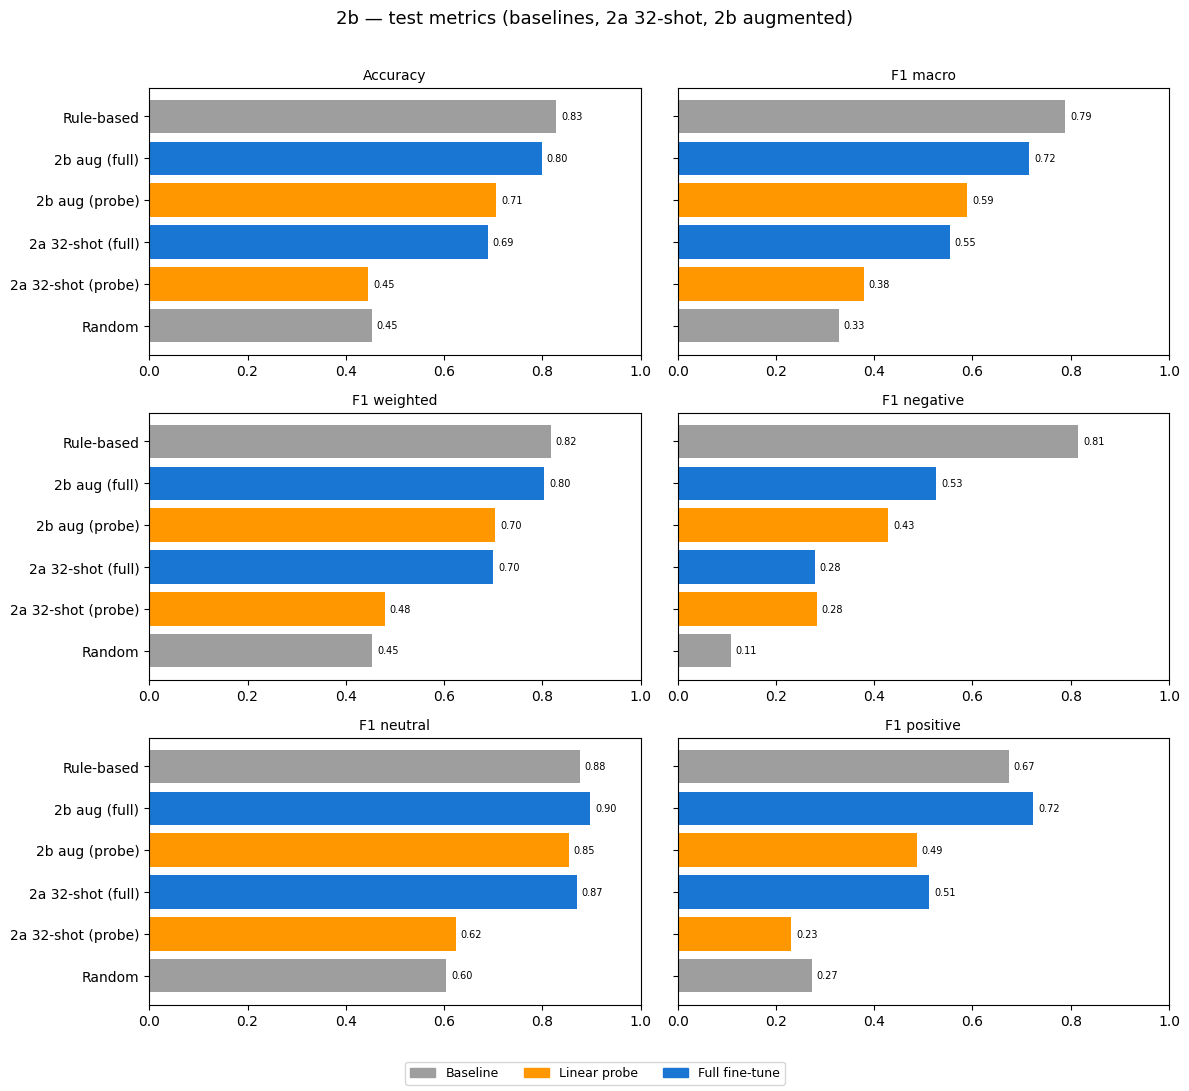

Last run: 2026-06-17 00:27:31


In [33]:
# watermark: AGLLM (AI-assisted content disclosure)
plot_metrics(['random', 'rule', '2a-probe', '2b-probe', '2a-full', '2b-full'],
             title='2b — test metrics (baselines, 2a 32-shot, 2b augmented)')

From 2b models, we can see that augmented data benefited both the full fine-tuning and frozen models.‍ F1 macro improved from 0.55 to 0.72 for full fine-tuning, and 0.38 to 0.59 for frozen.‍ However, we still see the class imbalance problem, the neutral class still performs the best, and the negative class performs the worst.‍ In addition, while data augmentation increased the overall metrics, it is still behind the rule-based model except on the neutral and positive classes, which the BERT model fine-tuned on augmented data already surpassed (the remaining gap is the negative class, 0.53 vs 0.81).‍

Thus, augmenting the 32 labeled data with about 200 sentences through back-translation improved the BERT model's performance but it is still behind the simple rule-based model.‍ The additional lexicon diversity and structural variety from the back-translation helped but because these are not genuinely new sentiments, the models couldn't close the gap on the hardest class (negative).‍

## 2c.‍ Zero shot.‍

For this part, we chose a deliberately minimal set-up, which is a single instruction prompt that asks the model to classify each test sentence as exactly one of `negative`, `neutral`, or `positive`.‍ Note that while we know we can improve this by providing annotator instructions (e.g.‍ using the investor's point of view, which we have learned from Part 1), we wanted to see how a basic prompt performs with a powerful LLM, which we chose to be the latest from Claude (Opus 4.8).‍

The code is in the notebook `part2_zeroshot_code.ipynb`.‍

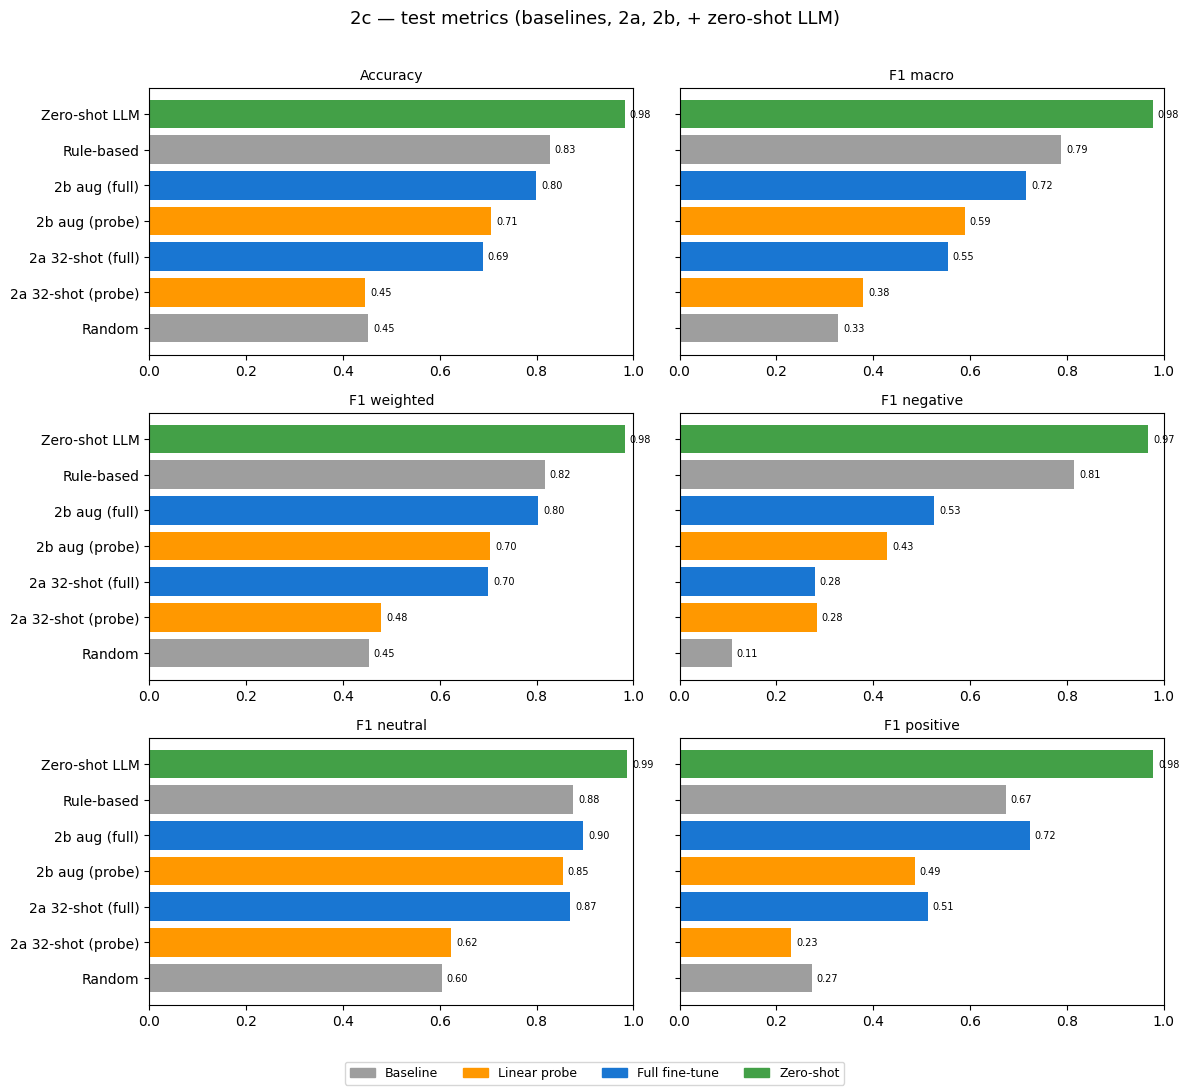

Last run: 2026-06-17 00:27:46


In [34]:
# watermark: AGLLM (AI-assisted content disclosure)
plot_metrics(['random', 'rule', '2a-probe', '2b-probe', '2a-full', '2b-full', 'zero-shot'],
             title='2c — test metrics (baselines, 2a, 2b, + zero-shot LLM)')

The zero-shot LLM gives the highest numbers in the project.‍ `claude-opus-4-8` reaches 0.978 macro-F1 with zero labelled examples, above 32-shot BERT (0.554), augmented BERT (0.716), and even the LLM-generated 2d run.‍ The per-class scores are uniformly strong (negative 0.968, neutral 0.987, positive 0.978), and there is no minority-class collapse like the one we saw in all the previous BERT models.‍

However, we need to consider potential benchmark contamination.‍ Financial PhraseBank is a public dataset and a frontier LLM has very likely seen it, or near-identical text, in pretraining.‍ A high score could measure partly the recall of a memorised benchmark rather than pure generalisation.‍ A clean re-test would require an out-of-distribution split that did not exist at the model's training cut-off.‍

In addition, if this model is put into production, we have some cost and latency problems.‍ Each prediction is a paid API call subject to rate limits and ~1.4 s pacing per request, which takes about 12 minutes for the 453-sentence test pass and recurring spend for any production deployment, against a fine-tuned local BERT that runs offline at near-zero marginal cost.‍ The LLM is also a black-box API.‍

## 2d.‍ Train on LLM-augmented data

We perform the same thing but this time using the 32 + LLM-generated sentences.‍ We fixed the number of LLM-generated sentences to be the same as the augmented set to make the performance comparable.‍

In [23]:
# watermark: AGLLM (AI-assisted content disclosure)
gen.shape #this consists of only the llm generated

(360, 6)

Last run: 2026-06-17 00:00:55


In [25]:
# watermark: AGLLM (AI-assisted content disclosure)
n_extra = len(aug) - len(labeled_32)                  # 229 - 32 = 197 generated rows to add
gen_sample = gen.sample(n=n_extra, random_state=SEED)
combo_2d = pd.concat([labeled_32[['text', 'label']], gen_sample[['text', 'label']]],
                     ignore_index=True)
assert len(combo_2d) == len(aug), f'2d set ({len(combo_2d)}) must size-match 2b augmented ({len(aug)})'

Last run: 2026-06-17 00:06:11


In [26]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- 2d (full): 32 real + size-matched LLM-generated sample, FULL fine-tuning, lr 2e-5 ---

method, cache_dir = 'llm-generated', '../.cache/bert_2d'
print('llm-generated set (size-matched to augmented):', len(combo_2d), 'rows ·',
      dict(combo_2d['label'].value_counts().sort_index()))

m = logged(method)
if m is None:
    trainer = train_bert(combo_2d, cache_dir, val_df=val, lr=2e-5, log_epochs=True, freeze_encoder=False)
    val_m = eval_split(trainer, val)
    m = eval_split(trainer, test)                      # TEST metrics -> logged below
    eu.log_result(MODEL, method, len(combo_2d), m,
                  notes=f"32 real + LLM-generated (random sample, size-matched to augmented); n={len(combo_2d)}; freeze_encoder=False; lr=2e-5; early_stop=val_f1_macro; val_f1_macro={val_m['f1_macro']:.4f}")
    print(f'[{method}] VAL :', fmt(val_m), '[trained]')
else:
    print(f'[{method}] [cached] (val macro-F1 is in the notes column of results.csv)')
gen_m = m
print(f'2d {method} TEST:', fmt(gen_m))
delta_vs(gen_m, '32-shot')
delta_vs(gen_m, 'augmented')

llm-generated set (size-matched to augmented): 229 rows · {0: np.int64(81), 1: np.int64(67), 2: np.int64(81)}


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.944580,0.878184,0.669604,0.602321,0.698187,0.465753,0.820084,0.521127
2,0.504593,0.473124,0.859031,0.821804,0.863916,0.771930,0.920755,0.772727
3,0.166109,0.445301,0.832599,0.801926,0.839633,0.757576,0.890625,0.757576
4,0.047953,0.606112,0.828194,0.797197,0.835902,0.742857,0.885375,0.763359
5,0.010614,0.544345,0.850220,0.828151,0.856000,0.812500,0.899225,0.772727
6,0.004541,0.565385,0.854626,0.827510,0.859898,0.788732,0.903475,0.790323
7,0.003018,0.650540,0.845815,0.817065,0.851779,0.777778,0.899225,0.774194
8,0.002251,0.674513,0.845815,0.818652,0.851672,0.788732,0.899225,0.768000


[llm-generated] VAL : {'accuracy': 0.8502, 'f1_macro': 0.8282, 'f1_weighted': 0.856, 'f1_negative': 0.8125, 'f1_neutral': 0.8992, 'f1_positive': 0.7727} [trained]
2d llm-generated TEST: {'accuracy': 0.8742, 'f1_macro': 0.8525, 'f1_weighted': 0.8771, 'f1_negative': 0.8485, 'f1_neutral': 0.919, 'f1_positive': 0.7901}
delta macro-F1 (vs 32-shot): +0.2988
delta macro-F1 (vs augmented): +0.1368
Last run: 2026-06-17 00:09:17


In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- 2d (frozen): 32 real + size-matched LLM-generated sample, LINEAR PROBE (encoder frozen), lr 1e-3 ---
# RESUME-AWARE: reuses the logged 'llm-generated-frozen' row. Same per-regime LR convention
# as 2a/2b's frozen probe (head-only, lr 1e-3). Reuses combo_2d built in the full 2d cell
# above (run it first). TEST metrics logged to results.csv.
method, cache_dir = 'llm-generated-frozen', '../.cache/bert_2d_frozen'
m = logged(method)
if m is None:
    trainer = train_bert(combo_2d, cache_dir, val_df=val, lr=1e-3, log_epochs=True, freeze_encoder=True)
    val_m = eval_split(trainer, val)
    m = eval_split(trainer, test)                      # TEST metrics -> logged below
    eu.log_result(MODEL, method, len(combo_2d), m,
                  notes=f"32 real + LLM-generated (random sample, size-matched to augmented); n={len(combo_2d)}; freeze_encoder=True; lr=1e-3; early_stop=val_f1_macro; val_f1_macro={val_m['f1_macro']:.4f}")
    print(f'[{method}] VAL :', fmt(val_m), '[trained]')
else:
    print(f'[{method}] [cached] (val macro-F1 is in the notes column of results.csv)')
gen_frozen_m = m
print(f'2d {method} TEST:', fmt(gen_frozen_m))

# ablation delta vs the full LLM-generated run (reads its TEST row from results.csv)
full_ref = logged('llm-generated')
if full_ref is not None:
    print(f"\nablation delta macro-F1 (frozen - full): "
          f"{float(gen_frozen_m['f1_macro']) - float(full_ref['f1_macro']):+.4f}")

  frozen encoder -> trainable 2,307/109,484,547 (0.00%, head only)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,1.163090,1.059016,0.453744,0.324749,0.442184,0.000000,0.540284,0.433962
2,1.061642,1.120193,0.383260,0.370689,0.413993,0.323232,0.473684,0.315152
3,0.965712,0.984342,0.519824,0.367452,0.511971,0.000000,0.643172,0.459184
4,0.987312,1.031263,0.466960,0.350341,0.472940,0.337349,0.681416,0.032258
5,0.907888,0.811891,0.665198,0.458981,0.611709,0.280000,0.818462,0.278481
6,0.912942,0.784468,0.651982,0.404166,0.591574,0.060606,0.804954,0.346939
7,0.905951,0.805030,0.656388,0.481389,0.620722,0.378378,0.828947,0.236842
8,0.877769,0.919648,0.603524,0.502842,0.617491,0.400000,0.782946,0.325581
9,0.850122,0.882859,0.616740,0.468059,0.601721,0.410256,0.814815,0.179104
10,0.836507,0.777321,0.700441,0.544380,0.674125,0.417910,0.858086,0.357143


[llm-generated-frozen] VAL : {'accuracy': 0.696, 'f1_macro': 0.5902, 'f1_weighted': 0.6988, 'f1_negative': 0.4375, 'f1_neutral': 0.8375, 'f1_positive': 0.4956} [trained]
2d llm-generated-frozen TEST: {'accuracy': 0.6733, 'f1_macro': 0.5447, 'f1_weighted': 0.672, 'f1_negative': 0.4, 'f1_neutral': 0.8495, 'f1_positive': 0.3846}

ablation delta macro-F1 (frozen - full): -0.3079
Last run: 2026-06-17 00:11:13


### 2d - analysis

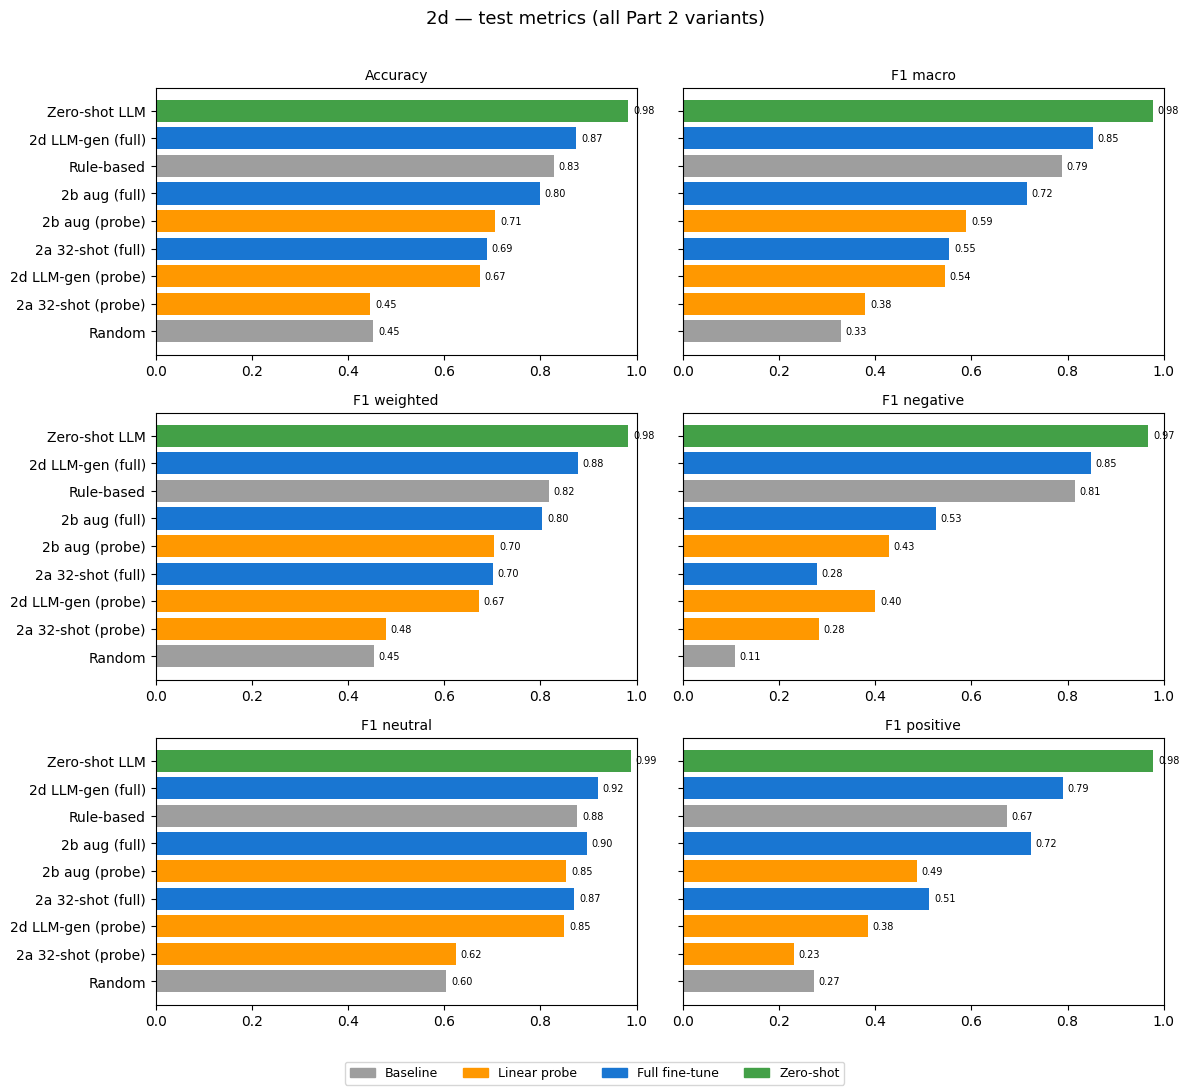

Last run: 2026-06-17 00:27:59


In [35]:
# watermark: AGLLM (AI-assisted content disclosure)
plot_metrics(list(CHART_VARIANTS),
             title='2d — test metrics (all Part 2 variants)')

With the training on LLM-augmented data, we have finally outperformed the rule-based model in all metrics using full fine-tuning (no freezing).‍ This means that not only is the augmented data able to capture the simple rules, it also added more information that these rules are not able to capture.‍ This could be the polarity switching that we have identified from Part 1.‍ We are closer, but still far from the Zero-shot LLM.‍

It is also very interesting that the linear probe (or frozen model) for the LLM-augmented data is not the best performing among the probe models.‍ This tells us that the additional information generated is most useful in updating the encoder.‍

## 2e.‍ Optimal technique

What we have seen from a–d is that the best training method is full fine-tuning on the LLM-augmented dataset.‍ Now, we will experiment on whether we should use the full generated LLM dataset, or combine it with the back-translated augmented dataset.‍

In [36]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- 2e: start from the best technique (full fine-tuning on LLM-generated data, 2d) and test
# two ways to push further, on the SAME protocol (full FT, lr 2e-5, early stopping on val):
#   A 'llm-full'     : 32 real + the FULL LLM-generated set (not size-matched -> simply more data)
#   B 'llm-bt-combo' : 32 real + LLM-generated + the back-translation paraphrases (curation test)
# Reference is the logged 2d row 'llm-generated' (32 + a size-matched LLM sample, 229 rows).
bt = aug.loc[aug['method'] != 'original', ['text', 'label']]    # back-translation paraphrases only (197)

sets_2e = {
    'llm-full':     pd.concat([labeled_32[['text', 'label']], gen[['text', 'label']]],
                              ignore_index=True).drop_duplicates('text', ignore_index=True),
    'llm-bt-combo': pd.concat([labeled_32[['text', 'label']], gen[['text', 'label']], bt],
                              ignore_index=True).drop_duplicates('text', ignore_index=True),
}

results_2e = {}
for method, train_df in sets_2e.items():
    print(f"\n=== {method}: {len(train_df)} rows ·",
          dict(train_df['label'].value_counts().sort_index()), "===")
    m = logged(method)
    if m is None:
        trainer = train_bert(train_df, f'../.cache/bert_2e_{method}', val_df=val,
                             lr=2e-5, log_epochs=True, freeze_encoder=False)
        val_m = eval_split(trainer, val)
        m = eval_split(trainer, test)                      # TEST metrics -> logged below
        eu.log_result(MODEL, method, len(train_df), m,
                      notes=f"2e; n={len(train_df)}; freeze_encoder=False; lr=2e-5; early_stop=val_f1_macro; val_f1_macro={val_m['f1_macro']:.4f}")
        print(f'[{method}] VAL :', fmt(val_m), '[trained]')
    else:
        print(f'[{method}] [cached] (val macro-F1 is in the notes column of results.csv)')
    results_2e[method] = m
    print(f'2e {method} TEST:', fmt(m))
    delta_vs(m, 'llm-generated')                           # vs the 2d size-matched best

# Scoreboard: 2d reference vs the two 2e candidates, sorted by macro-F1.
board_src = {'2d  32 + LLM (size-matched, 229)':   logged('llm-generated'),
             '2e-A  32 + ALL LLM (llm-full)':      results_2e['llm-full'],
             '2e-B  32 + LLM + BT (llm-bt-combo)': results_2e['llm-bt-combo']}
board = (pd.DataFrame({k: v for k, v in board_src.items() if v is not None}).T
         [['accuracy', 'f1_macro', 'f1_negative', 'f1_neutral', 'f1_positive']].astype(float)
         .sort_values('f1_macro', ascending=False))
print('\nPart 2e scoreboard (test), sorted by macro-F1:')
print(board.round(4))


=== llm-full: 392 rows · {0: np.int64(131), 1: np.int64(130), 2: np.int64(131)} ===


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.752480,0.614254,0.819383,0.776454,0.826288,0.692308,0.885375,0.751678
2,0.157695,0.438429,0.867841,0.819832,0.869378,0.746269,0.931408,0.781818
3,0.030588,0.640612,0.854626,0.823691,0.860735,0.781250,0.911197,0.778626
4,0.003754,0.685037,0.854626,0.810065,0.861464,0.739726,0.927757,0.762712
5,0.015083,0.618944,0.867841,0.822997,0.872419,0.746667,0.933333,0.788991
6,0.002218,0.566682,0.881057,0.848580,0.884398,0.806452,0.932836,0.806452
7,0.001140,0.748376,0.859031,0.823278,0.864771,0.757576,0.915385,0.796875
8,0.000904,0.762709,0.859031,0.823278,0.864771,0.757576,0.915385,0.796875
9,0.000764,0.775665,0.859031,0.823278,0.864771,0.757576,0.915385,0.796875


[llm-full] VAL : {'accuracy': 0.8811, 'f1_macro': 0.8486, 'f1_weighted': 0.8844, 'f1_negative': 0.8065, 'f1_neutral': 0.9328, 'f1_positive': 0.8065} [trained]
2e llm-full TEST: {'accuracy': 0.9029, 'f1_macro': 0.8743, 'f1_weighted': 0.9025, 'f1_negative': 0.855, 'f1_neutral': 0.946, 'f1_positive': 0.8219}
delta macro-F1 (vs llm-generated): +0.0218

=== llm-bt-combo: 589 rows · {0: np.int64(198), 1: np.int64(193), 2: np.int64(198)} ===


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.612112,0.420630,0.845815,0.808618,0.851586,0.754098,0.908397,0.763359
2,0.078205,0.585958,0.854626,0.829553,0.860097,0.800000,0.903475,0.785185
3,0.027154,0.664847,0.854626,0.835672,0.859424,0.818182,0.894942,0.793893
4,0.001967,0.959278,0.832599,0.817393,0.840741,0.813559,0.880000,0.758621
5,0.001250,0.870744,0.850220,0.828130,0.855997,0.794118,0.893281,0.796992
6,0.000845,0.909638,0.850220,0.830099,0.856070,0.805970,0.893281,0.791045


[llm-bt-combo] VAL : {'accuracy': 0.8546, 'f1_macro': 0.8357, 'f1_weighted': 0.8594, 'f1_negative': 0.8182, 'f1_neutral': 0.8949, 'f1_positive': 0.7939} [trained]
2e llm-bt-combo TEST: {'accuracy': 0.8786, 'f1_macro': 0.8522, 'f1_weighted': 0.882, 'f1_negative': 0.8028, 'f1_neutral': 0.9184, 'f1_positive': 0.8354}
delta macro-F1 (vs llm-generated): -0.0003

Part 2e scoreboard (test), sorted by macro-F1:
                                    accuracy  f1_macro  f1_negative  \
2e-A  32 + ALL LLM (llm-full)         0.9029    0.8743       0.8550   
2d  32 + LLM (size-matched, 229)      0.8742    0.8525       0.8485   
2e-B  32 + LLM + BT (llm-bt-combo)    0.8786    0.8522       0.8028   

                                    f1_neutral  f1_positive  
2e-A  32 + ALL LLM (llm-full)           0.9460       0.8219  
2d  32 + LLM (size-matched, 229)        0.9190       0.7901  
2e-B  32 + LLM + BT (llm-bt-combo)      0.9184       0.8354  
Last run: 2026-06-17 01:23:31


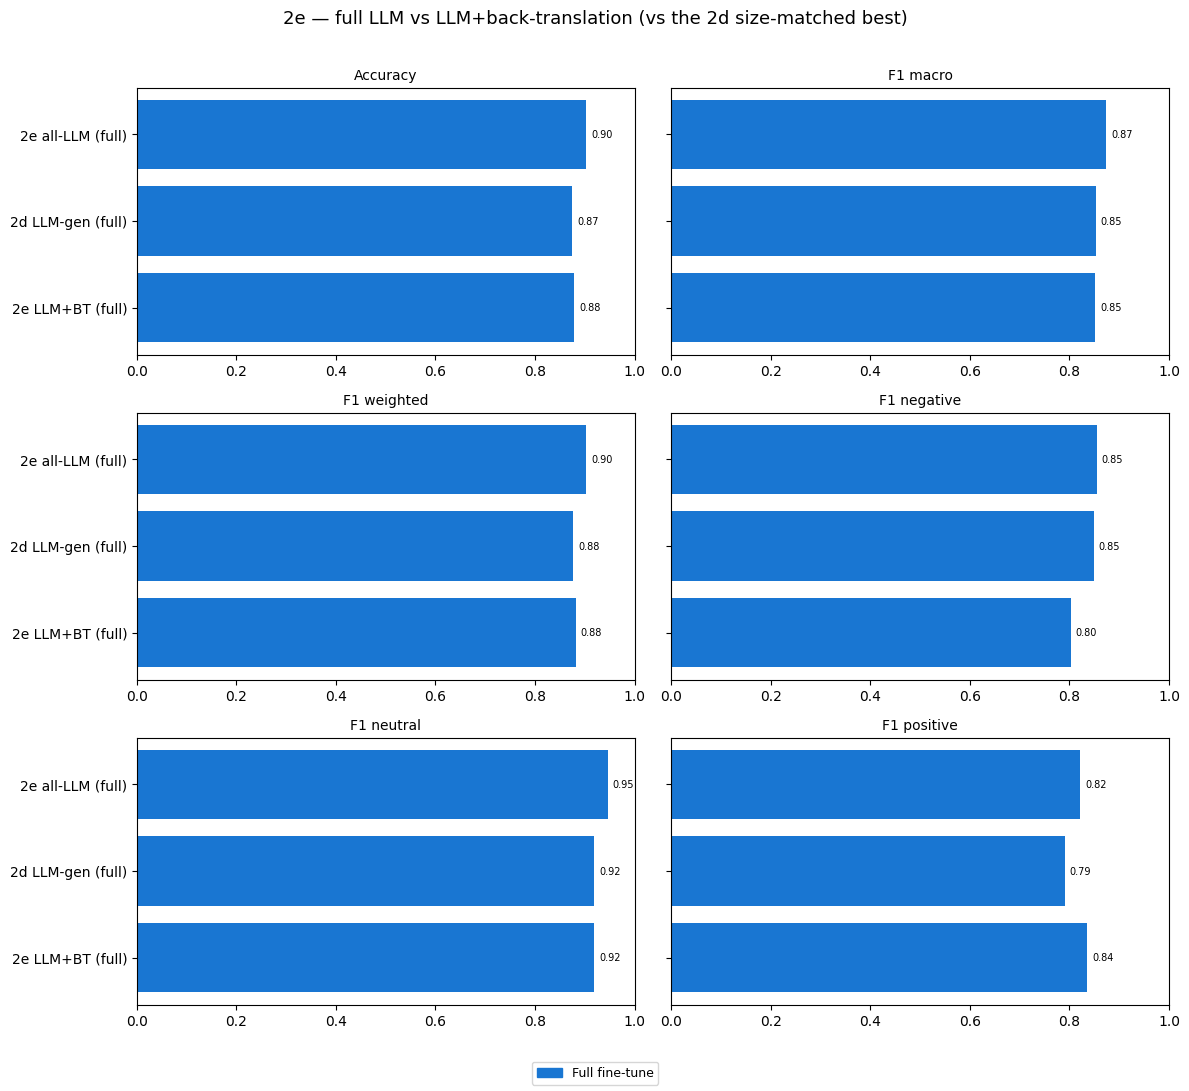

Last run: 2026-06-17 01:26:34


In [38]:
# watermark: AGLLM (AI-assisted content disclosure)
plot_metrics(['2d-full', '2e-full', '2e-combo'],
             title='2e — full LLM vs LLM+back-translation (vs the 2d size-matched best)')

From the performance metrics, we can see that the 2e-A (`llm-full`) variant, which uses all the LLM-generated data + 32, achieves the highest score on every metric except F1 positive, where it loses to the combo only by a small amount (0.82 vs 0.84).‍ Compared to the 2d run, going from 229 to 392 rows of LLM data increases F1 macro from 0.85 to 0.87, so adding more LLM-generated data does help.‍

The 2e-B (`llm-bt-combo`) variant shows that mixing the back-translation (BT) paraphrases into the LLM data does not help.‍ Despite having the most data (589 rows), its F1 macro(0.85) is no better than 2d and below `llm-full`, and its negative-class F1 actually drops to 0.80, below both `llm-full` (0.85) and even 2d (0.85).‍ The BT paraphrases create noise on the signals from LLM for the hardest class.‍ So the lesson is not that more data is always better, but that more LLM-generated data helps while augmenting it with back-translation hurts.‍

Thus, the best technique is full fine-tuning on LLM-generated data alone, scaled up.‍ However, the gain is modest (+0.02 F1 macro for +163 rows) which tells us that there are diminishing returns.‍ How far this keeps paying off, and whether performance eventually plateaus or degrades, is a scaling question that requires more generated data, which is currently outside our Groq free-tier daily token limit.‍ 